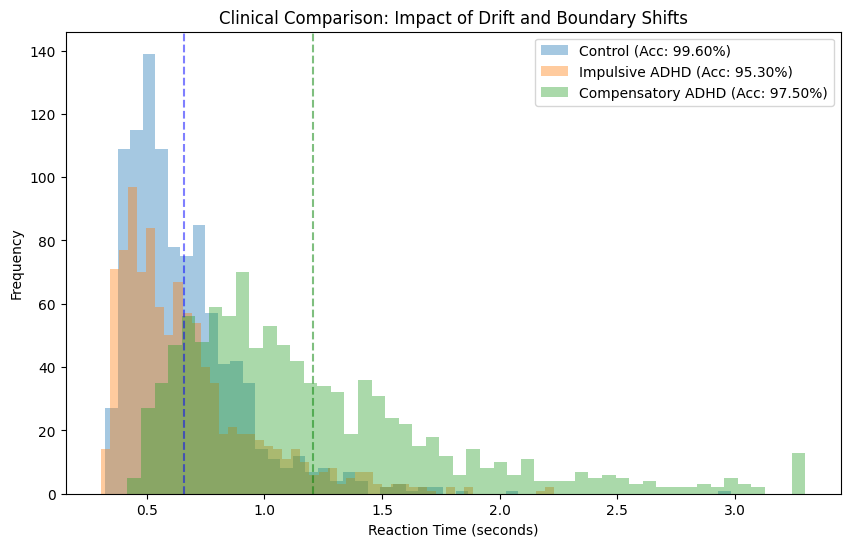

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def run_clinical_trial(v, a, Ter, sigma=0.1, dt=0.001, max_t=3.0):
    evidence = 0
    t = 0
    # SDE Implementation: Accumulate until boundary 'a' or '-a' is hit
    while abs(evidence) < a and t < max_t:
        evidence += v * dt + sigma * np.sqrt(dt) * np.random.normal()
        t += dt
    # Return total RT (Decision Time + Non-Decision Time) and accuracy
    return t + Ter, (1 if evidence >= a else 0)

# 1. Control Group (Standard)
v_con, a_con, Ter_con = 0.25, 0.10, 0.25

# 2. Impulsive ADHD (Lower threshold, lower drift)
v_imp, a_imp, Ter_imp = 0.18, 0.08, 0.25 

# 3. Adult Compensatory ADHD (Mowinckel et al. findings: high 'a', low 'v')
# Shift drift by -1.62 and boundary by +0.9 (scaled for simulation)
v_comp, a_comp, Ter_comp = 0.15, 0.14, 0.30 

def gather_data(v, a, Ter, n=1000):
    results = [run_clinical_trial(v, a, Ter) for _ in range(n)]
    rts = [r[0] for r in results]
    acc = sum([r[1] for r in results]) / n
    return rts, acc

# Execute Simulations
con_rts, con_acc = gather_data(v_con, a_con, Ter_con)
imp_rts, imp_acc = gather_data(v_imp, a_imp, Ter_imp)
comp_rts, comp_acc = gather_data(v_comp, a_comp, Ter_comp)

# Visualize Clinical RT Distributions
plt.figure(figsize=(10, 6))
plt.hist(con_rts, bins=50, alpha=0.4, label=f'Control (Acc: {con_acc:.2%})')
plt.hist(imp_rts, bins=50, alpha=0.4, label=f'Impulsive ADHD (Acc: {imp_acc:.2%})')
plt.hist(comp_rts, bins=50, alpha=0.4, label=f'Compensatory ADHD (Acc: {comp_acc:.2%})')
plt.axvline(np.mean(con_rts), color='blue', linestyle='dashed', alpha=0.5)
plt.axvline(np.mean(comp_rts), color='green', linestyle='dashed', alpha=0.5)
plt.title("Clinical Comparison: Impact of Drift and Boundary Shifts")
plt.xlabel("Reaction Time (seconds)")
plt.ylabel("Frequency")
plt.legend()
plt.show()



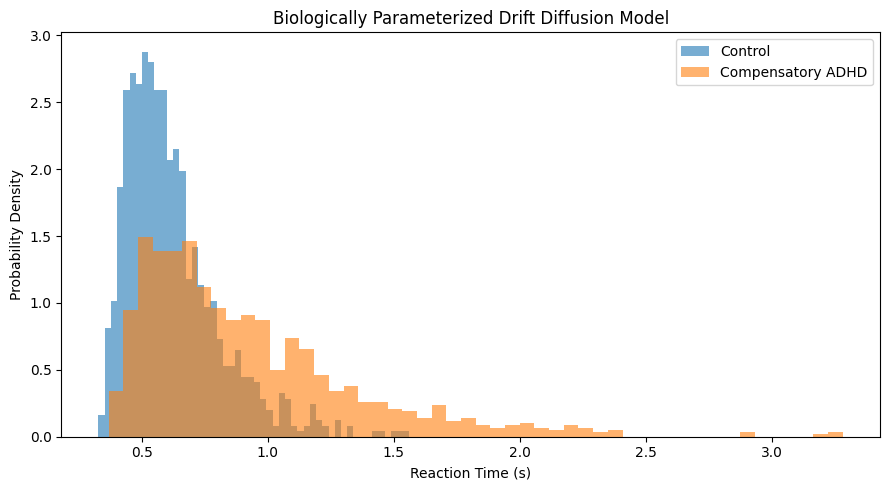

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# ============================================================
# Brain State
# ============================================================
# This class represents the functional state of several
# brain regions involved in perceptual decision making.
#
# These values are NOT neural firing rates.
# Instead, they are abstract measures of how effectively
# each brain region contributes to the decision process.
# ============================================================

@dataclass
class BrainState:

    # Evidence quality generated by dlPFC
    dlPFC_signal: float

    # Cognitive effort / conflict estimated by dmPFC
    dmPFC_effort: float

    # Precision of attentional and oculomotor circuits
    # (represented here by the Superior Colliculus)
    SC_precision: float

    # Response caution
    # (associated with pre-SMA / basal ganglia circuits)
    preSMA_caution: float

    # Additional motor preparation delay
    # (Frontal Eye Fields contribution)
    FEF_conflict: float


# ============================================================
# Biological Mapper
# ============================================================
# Converts neural circuit properties into the latent
# parameters of a Drift Diffusion Model.
# ============================================================

class BiologicalMapper:

    def map_to_ddm(self, brain):

        # ----------------------------------------------------
        # Drift Rate
        #
        # Better cortical evidence increases drift.
        # Higher perceived effort reduces effective evidence.
        # ----------------------------------------------------

        drift = brain.dlPFC_signal - brain.dmPFC_effort

        # ----------------------------------------------------
        # Noise
        #
        # Better attentional precision
        # -> lower stochastic variability
        # ----------------------------------------------------

        sigma = 0.10 / brain.SC_precision

        # ----------------------------------------------------
        # Decision Threshold
        #
        # Higher caution
        # -> more evidence required before responding
        # ----------------------------------------------------

        boundary = brain.preSMA_caution

        # ----------------------------------------------------
        # Non-decision Time
        #
        # Includes sensory encoding,
        # motor preparation,
        # and response execution.
        # Here we model additional delay due to FEF conflict.
        # ----------------------------------------------------

        nondecision = 0.20 + brain.FEF_conflict

        return drift, sigma, boundary, nondecision


# ============================================================
# Drift Diffusion Model
# ============================================================

class BioDDM:

    def __init__(self, dt=0.001):

        self.dt = dt
        self.sqrt_dt = np.sqrt(dt)

    def simulate_trial(self, drift, sigma, boundary, nondecision):

        evidence = 0.0
        t = 0.0

        max_time = 3.0

        while abs(evidence) < boundary and t < max_time:

            # Euler-Maruyama integration
            evidence += (
                drift * self.dt
                + sigma * self.sqrt_dt * np.random.normal()
            )

            t += self.dt

        choice = 1 if evidence >= boundary else 0

        return t + nondecision, choice


# ============================================================
# Experimental Conditions
# ============================================================

control = BrainState(

    dlPFC_signal = 0.30,
    dmPFC_effort = 0.02,
    SC_precision = 1.20,
    preSMA_caution = 0.10,
    FEF_conflict = 0.05

)

adhd_comp = BrainState(

    dlPFC_signal = 0.22,
    dmPFC_effort = 0.04,

    SC_precision = 0.95,

    preSMA_caution = 0.12,

    FEF_conflict = 0.08

)

# ============================================================
# Simulation
# ============================================================

mapper = BiologicalMapper()

model = BioDDM()

N = 1000

control_rt = []
adhd_rt = []

for _ in range(N):

    params = mapper.map_to_ddm(control)

    rt, _ = model.simulate_trial(*params)

    control_rt.append(rt)


for _ in range(N):

    params = mapper.map_to_ddm(adhd_comp)

    rt, _ = model.simulate_trial(*params)

    adhd_rt.append(rt)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(9,5))

plt.hist(
    control_rt,
    bins=50,
    alpha=0.6,
    density=True,
    label="Control"
)

plt.hist(
    adhd_rt,
    bins=50,
    alpha=0.6,
    density=True,
    label="Compensatory ADHD"
)

plt.xlabel("Reaction Time (s)")
plt.ylabel("Probability Density")

plt.title("Biologically Parameterized Drift Diffusion Model")

plt.legend()

plt.tight_layout()

plt.show()